In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
K = 252

**Chargement des prix**

In [ ]:
prices = pd.read_csv("df_train.csv", sep=";", index_col=0)

**Visualitation des données**

In [ ]:
prices.head(10)

,Asset1,Asset2,Asset3,Asset4,Asset5,Asset6,Asset7,Asset8,Asset9,Asset10,Asset11,Asset12,Asset13,Asset14,Asset15
0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
1,100.08,100.36,99.39,100.85,100.93,99.99,100.51,100.46,100.45,100.61,100.27,100.61,98.49,98.95,100.23
2,100.00,99.84,99.31,100.47,100.55,98.95,100.91,101.05,100.05,99.69,100.11,100.90,98.29,99.51,100.88
3,102.34,101.17,101.96,101.05,102.69,101.15,101.41,100.35,100.75,101.78,101.44,102.88,97.77,101.50,100.18
4,95.55,96.72,96.15,98.21,95.56,97.04,101.21,99.41,98.10,99.31,97.80,94.61,102.33,96.50,100.22
5,93.39,95.10,95.12,96.78,92.37,94.83,100.56,98.58,97.52,97.81,96.03,92.85,102.52,93.84,102.84
6,94.88,97.11,96.51,98.41,95.43,97.18,100.58,99.44,99.77,99.04,97.74,94.20,101.96,96.92,103.03
7,97.12,99.09,98.09,99.26,98.12,99.22,101.91,100.38,101.47,100.79,99.40,96.65,102.63,101.03,102.48
8,99.19,102.11,98.84,100.53,99.63,95.90,102.70,100.36,102.88,102.16,100.75,97.62,102.20,97.89,101.99
9,100.03,102.14,98.11,100.83,98.98,96.30,102.41,99.76,102.99,101.50,100.95,98.46,103.62,99.23,102.19


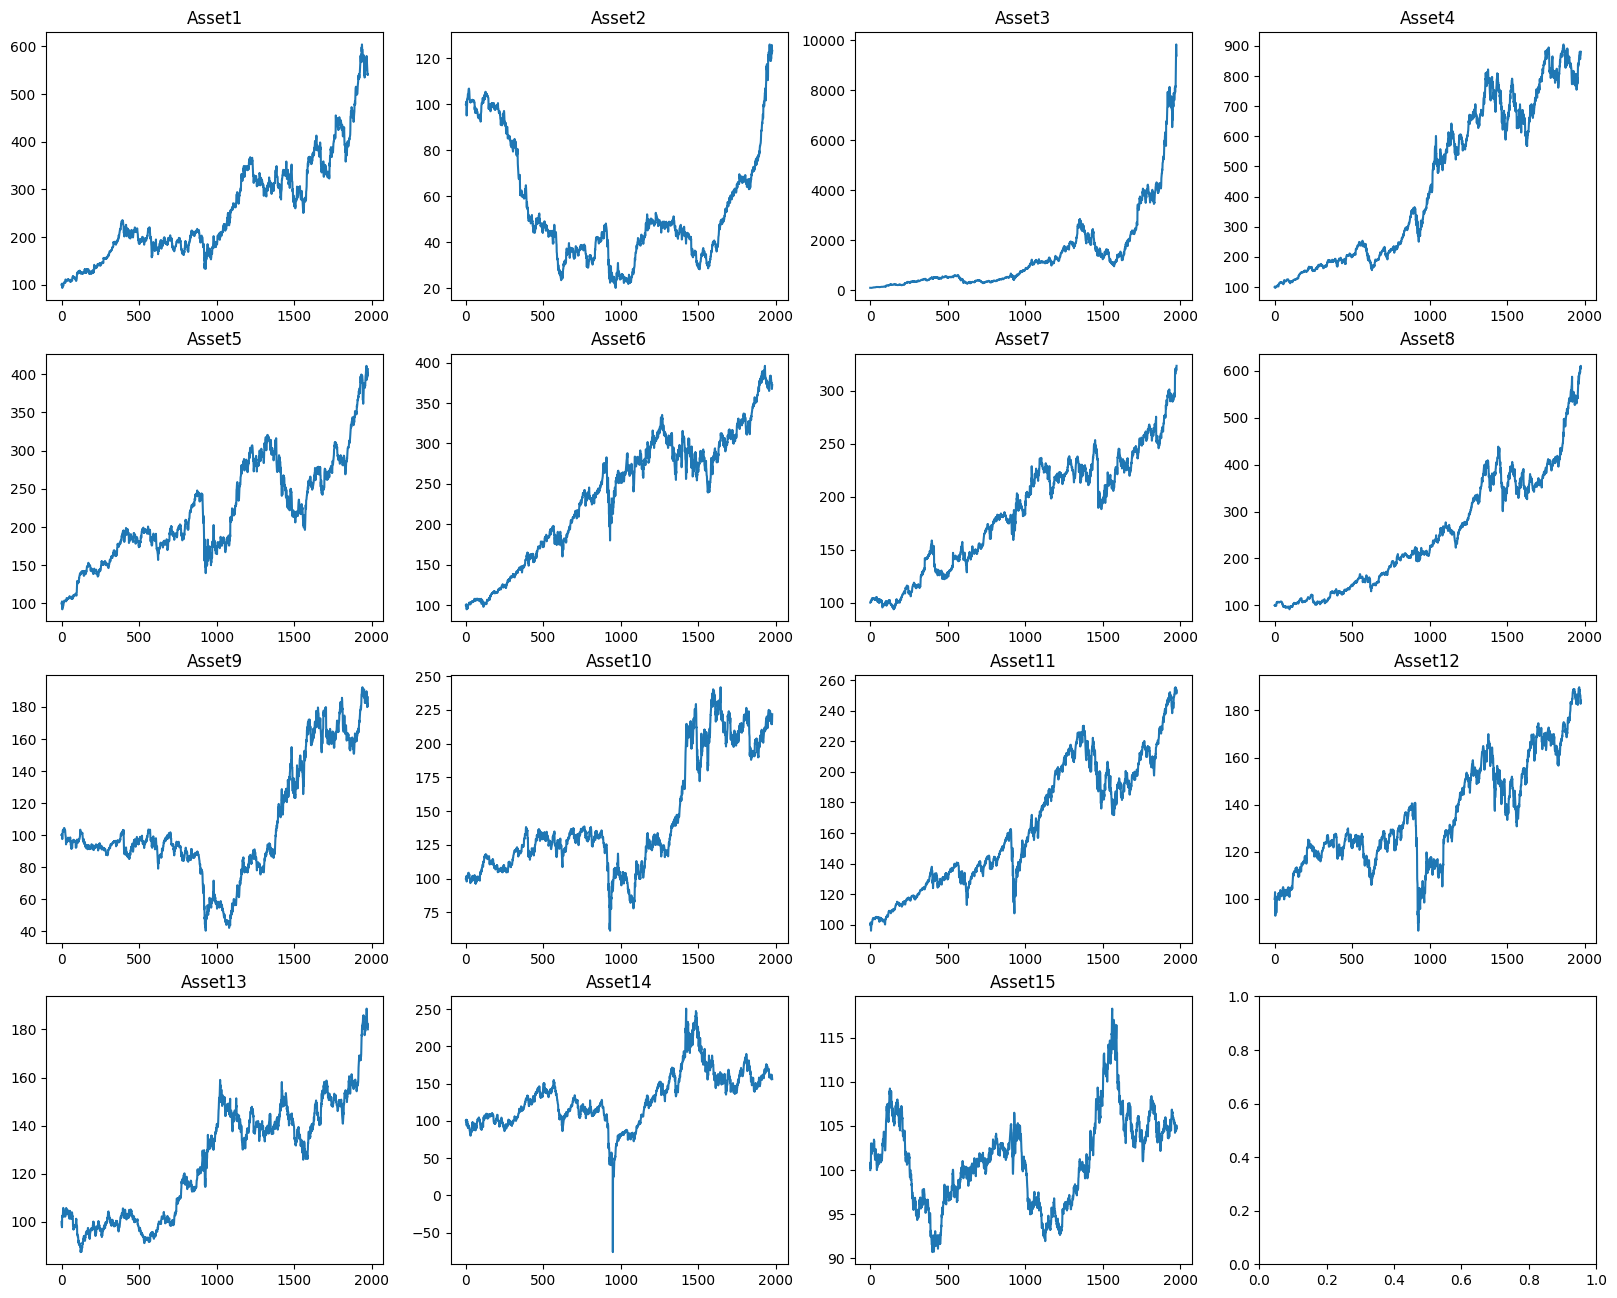

In [ ]:
fig, ax = plt.subplots(4,4, figsize=(20,16))
j,k = 0,0
for i,asset in enumerate(prices.columns):
    ax[j,k].plot(prices[asset])
    ax[j,k].set_title(asset)
    if k < 3:
        k+=1
    else:
        k=0
        j+=1

**Matrice de corrélation entre les actifs**

Cette matrice permet de visualiser les relations entre les rendements des actifs.  
Elle aide à comprendre pourquoi le filtre de décorrélation peut rejeter certains actifs : deux actifs avec une corrélation très élevée apportent peu de diversification.

In [ ]:
# Matrice de corrélation entre les actifs
# On utilise les rendements, pas les prix, car la corrélation doit mesurer les co-mouvements des variations.
asset_returns = prices.pct_change().dropna()
corr_assets = asset_returns.corr()

plt.figure(figsize=(14, 12))
im = plt.imshow(corr_assets, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im, fraction=0.046, pad=0.04, label="Corrélation")

plt.xticks(range(len(corr_assets.columns)), corr_assets.columns, rotation=90)
plt.yticks(range(len(corr_assets.index)), corr_assets.index)

# Affichage des valeurs dans chaque case
for i in range(len(corr_assets.index)):
    for j in range(len(corr_assets.columns)):
        plt.text(j, i, f"{corr_assets.iloc[i, j]:.2f}",
                 ha="center", va="center", fontsize=8)

plt.title("Matrice de corrélation des rendements des actifs")
plt.tight_layout()
plt.show()

# Version utile pour comprendre le filtre de décorrélation : corrélation absolue
# Le filtre compare |corrélation| avec corr_threshold.
abs_corr_assets = corr_assets.abs()

plt.figure(figsize=(14, 12))
im = plt.imshow(abs_corr_assets, vmin=0, vmax=1, cmap="Reds")
plt.colorbar(im, fraction=0.046, pad=0.04, label="Corrélation absolue")

plt.xticks(range(len(abs_corr_assets.columns)), abs_corr_assets.columns, rotation=90)
plt.yticks(range(len(abs_corr_assets.index)), abs_corr_assets.index)

for i in range(len(abs_corr_assets.index)):
    for j in range(len(abs_corr_assets.columns)):
        plt.text(j, i, f"{abs_corr_assets.iloc[i, j]:.2f}",
                 ha="center", va="center", fontsize=8)

plt.title("Matrice de corrélation absolue utilisée par le filtre")
plt.tight_layout()
plt.show()

**Quelques fonctions de base**

In [ ]:
def normalize_price(serie):
    '''
    -serie (pd.Serie) : série de prix
    Normalise la série avec le prix à t_0 = 100
    '''
    s = serie/serie.shift(1)
    s.iloc[0] = 100
    return s.cumprod()

def get_returns(df):
    '''
    -df (pd.DataFrame ou pd.Series) : dataframe ou série des prix
    Renvoie les returns
    '''
    return (df/df.shift(1)).dropna()

def get_cagr(serie):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    Cumulative Annual Growth Return
    '''
    return round(float(((serie.iloc[-1]/serie.iloc[0])**(1/(len(serie)/252))) - 1), 4)

def get_vol(serie):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    Annualized Volatility
    '''
    return round(float(get_returns(serie).std() * np.sqrt(252)), 4)

def get_sr(serie, r=0.0):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    -r (float) : taux d'intérêt (à 0 pour le projet)
    Annualized Sharpe Ratio
    '''
    return round(float((get_cagr(serie) - r) / get_vol(serie)), 4)

def get_calmar(serie):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    Calmar Ratio
    '''
    return round(get_cagr(serie)/get_mdd(serie), 4)

def get_mdd(serie):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    Max Drawdown
    '''
    running_max = np.maximum.accumulate(serie)
    drawdowns   = (serie - running_max) / running_max
    trough_idx  = int(np.argmin(drawdowns))
    mdd         = -drawdowns.iloc[trough_idx]
    return round(float(mdd), 4)

def get_corr(serie, benchmark):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    -benchmark (pd.Serie) : série de prix du benchmark (généralement S&P500)
    Correlation
    '''
    return round(float(np.corrcoef(get_returns(serie), get_returns(benchmark))[0,1]), 4)

def overall_score(serie, benchmark):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    -benchmark (pd.Serie) : série de prix du benchmark (généralement S&P500)
    Personnalized selection score
    '''
    return round((0.5*get_sr(serie) + 0.5*get_calmar(serie))/get_corr(serie, benchmark),4)

def compute_metrics(serie, benchmark):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    -benchmark (pd.Serie) : série de prix du benchmark (généralement S&P500)
    Compute all metrics
    '''
    print(f"CAGR : {round(get_cagr(serie) * 100, 4)} %")
    print(f"Annualized Vol : {round(get_vol(serie)* 100, 4)} %")
    print(f"Sharpe Ratio : {round(get_sr(serie), 4)}")
    print(f"Calmar Ratio : {round(get_calmar(serie), 4)}")
    print(f"Max Drawdown : {round(get_mdd(serie)*100,4)} %")
    print(f"Corr-bench : {round(float(get_corr(serie, benchmark)), 4)}")
    print(f"Overall score : {overall_score(serie, benchmark)}")

#### Fonction à compléter
La fonction doit prendre en entrée un dataframe de taille 252 (moins de données pourront être utilisées dans la fonction si nécessaire) et renvoyer un vecteur (np.array, shape (15,)) de taille 15 comprenant les poids des asset 1 à 15. Il y a deux contraintes sur le vecteur :

- Les poids sont positifs.

- La somme des poids est égale ou inférieure à 1


In [ ]:
def compute_weights(df, max_assets=5, corr_threshold=0.75, lookback_momentum=60):
    """
    Calcule les poids du portefeuille avec :
    1) un filtre momentum,
    2) un filtre de décorrélation entre actifs,
    3) une pondération inverse-volatilité.

    Paramètres
    ----------
    df : pd.DataFrame
        Fenêtre de prix des actifs.
    max_assets : int
        Nombre maximal d'actifs retenus.
    corr_threshold : float
        Seuil maximal de corrélation absolue autorisé entre deux actifs retenus.
        Exemple : 0.75 signifie qu'on évite de garder deux actifs corrélés à plus de 75%.
    lookback_momentum : int
        Nombre de jours utilisés pour calculer le momentum.

    Retour
    ------
    np.array
        Vecteur de poids positif, de somme <= 1, de taille len(df.columns).
    """

    prices = df.copy()
    returns = prices.pct_change().dropna()

    if len(prices) < 2 or returns.empty:
        return np.zeros(len(df.columns))

    lookback = min(lookback_momentum, len(prices) - 1)

    # Momentum sur la fenêtre choisie
    momentum = prices.iloc[-1] / prices.iloc[-lookback] - 1
    momentum = momentum.replace([np.inf, -np.inf], np.nan).dropna()

    # On garde seulement les actifs avec un momentum positif
    momentum = momentum[momentum > 0]

    if len(momentum) == 0:
        return np.zeros(len(df.columns))

    # Classement des actifs par momentum décroissant
    ranked_assets = momentum.sort_values(ascending=False).index

    # ========= Filtre de décorrélation des actifs =========
    # Objectif : éviter de sélectionner plusieurs actifs qui évoluent presque pareil.
    # On parcourt les actifs du meilleur momentum au moins bon et on garde un actif
    # seulement si sa corrélation absolue avec les actifs déjà retenus reste sous le seuil.
    corr_matrix = returns[ranked_assets].corr().abs()

    selected_assets = []
    for asset in ranked_assets:
        if len(selected_assets) >= max_assets:
            break

        if len(selected_assets) == 0:
            selected_assets.append(asset)
        else:
            max_corr_with_selected = corr_matrix.loc[asset, selected_assets].max()
            if pd.isna(max_corr_with_selected) or max_corr_with_selected < corr_threshold:
                selected_assets.append(asset)

    if len(selected_assets) == 0:
        return np.zeros(len(df.columns))

    # Volatilité des actifs retenus
    vol = returns[selected_assets].std().replace(0, np.nan)

    # Risk parity simple : poids proportionnels à l'inverse de la volatilité
    inv_vol = 1 / (vol + 1e-8)
    inv_vol = inv_vol.replace([np.inf, -np.inf], np.nan).dropna()

    if len(inv_vol) == 0:
        return np.zeros(len(df.columns))

    weights = inv_vol / inv_vol.sum()

    final_weights = pd.Series(0.0, index=df.columns)
    final_weights[weights.index] = weights

    return final_weights.values


#### Benchmark Simple - Equally weighted
Une méthode simple de répartition des poids serait de répartir la valeur du portefeuille de manière équipondérée

In [ ]:
eq_weighted_portfolio = normalize_price(((prices*1/15).sum(axis=1)).iloc[K:])

**Fonction permettant de valider les poids**

In [ ]:
def check_weights(w):
    '''
    -w (np.array, shape : (15,)) : Vecteur des poids
    Renvoie False si les poids ne respectent pas les contraintes
    '''
    if round(w.sum(), 3)<=1 and (w<0).sum()==0:
        return True
    else:
        print("Poids négatifs ou somme supérieure à 1")
        print(f"Poids {w}")
        print(f"Somme : {w.sum()}")
        return False

**Chargement des autres benchmark**

In [ ]:
df_benchmark = pd.read_csv("df_benchmark.csv", sep=";", index_col=0)
secret_bench = normalize_price(df_benchmark["Secret"])
sp500 = normalize_price(df_benchmark["SP500"])

**Backtest la stratégie**

In [ ]:
def backtest():
    # Calculate Weights
    weights_t = []
    for i in range(len(prices) - K + 1):
        w = compute_weights(prices.iloc[i:i + K])
        if check_weights(w):
            weights_t.append(w)
        else:
            break

    weights_array = np.array(weights_t)

    # Calculate portfolio value and returns
    pr = (weights_array[1:-1] * get_returns(prices).iloc[K:]).sum(axis=1)

    portfolio = [100]
    for i in range(len(pr)):
        portfolio.append(pr.iloc[i] * portfolio[-1])

    portfolio = pd.Series(portfolio)
    portfolio.index = sp500.index

    print("==========PORTFOLIO===========")
    compute_metrics(portfolio, sp500)
    print("==========S&P500==============")
    compute_metrics(sp500, sp500)
    print("==========EQ-WEIGHTED=========")
    compute_metrics(eq_weighted_portfolio, sp500)
    print("======SECRET-BENCHMARK========")
    compute_metrics(secret_bench, sp500)

    # Courbe de performance
    plt.figure(figsize=(20, 12))
    plt.plot(portfolio)
    plt.plot(sp500)
    plt.plot(eq_weighted_portfolio)
    plt.plot(secret_bench)
    plt.legend(["Portfolio", "S&P500", "Eq-Weighted", "Secret"])
    plt.title("Évolution de la performance du portefeuille")
    plt.xlabel("Date")
    plt.ylabel("Valeur normalisée")
    plt.grid(True)

    # ========= Courbe d'évolution des poids =========
    # Les poids utilisés pour calculer les rendements commencent à weights_array[1:-1].
    weights_df = pd.DataFrame(
        weights_array[1:-1],
        index=get_returns(prices).iloc[K:].index,
        columns=prices.columns
    )

    plt.figure(figsize=(20, 12))
    for asset in weights_df.columns:
        plt.plot(weights_df.index, weights_df[asset], label=asset)

    plt.title("Évolution des poids des actifs dans le portefeuille")
    plt.xlabel("Date")
    plt.ylabel("Poids")
    plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
    plt.grid(True)
    plt.tight_layout()

    return portfolio


In [ ]:
strat1 = backtest()
